In [1]:
import os
import sys
dir_path = "/qumulo/shared_data/aofei_summer/RegTok/RegLLM"
sys.path.insert(0, dir_path)
os.environ['CUDA_VISIBLE_DEVICES'] = "3"
os.environ["HF_HUB_CACHE"]="/qumulo/shared_data/aofei_summer/LLMs"
from llava.eval.cli_v1 import RegLLMChatbot

/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/qumulo/shared_data/aofei_summer/miniconda3/lib/python3.13/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:

# model_dir = "/qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/ablation_noregion_71k_nosep"
# model_dir = "/qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/1107_ablation_71k_seg_token"
model_dir = "/qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/ablation_1110_full_instruct_71k_no_stage1"


model_args = {
        "model_name_or_path": "Qwen/Qwen3-8B",
        "pretrained_llm_path": model_dir,
        "tokenizer_path": model_dir,
        "peft_path": None,
        "regtok_config_path": "/qumulo/shared_data/aofei_summer/RegTok/source/tokenizer/regtok_config.yaml",
        "regtok_weight_path": "/qumulo/shared_data/aofei_summer/intern_records/RegTok/checkpoints/RegTok_pipeline_full_wo_quant/002-RegTok/checkpoints/0079280.pt",
        "use_regtok": True,
        "mm_vision_vq_type": "RegTok",
        "vision_tower": "/qumulo/shared_data/aofei_summer/CLIPs/unimed_clip_vit_l14.pt",
        "mm_use_im_start_end": False,
        "mm_use_im_patch_token": True,
        "mm_vision_select_feature": "patch",
        "mm_patch_merge_type": "flat",
        "mm_projector_type": "mlp2x_gelu",
        "pretrain_mm_mlp_adapter": None,
        "mm_vision_select_layer": -1,
        "use_region_tokens": True,
        "use_sep_proj": False,
        "use_seg_loss": True,
        "output_segmentation": True,
        "modality_num": 18,
        "codebook_size": 32,
        "train_all_embeddings": True,
        "load_codebook_embeddings": False,
        "use_lightweight_decoder": False,
        "resize_embedding": False,
        # "lora_r": 64,
        # "lora_alpha": 64,
        # # "lora_dropout": 0.05,
        "use_moe": False,

    }

In [3]:
bot = RegLLMChatbot(model_dir, model_args=model_args, device="cuda")

loading model from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/ablation_1110_full_instruct_71k_no_stage1
use RegSegForCausalLM!
576 codebook_token_ids
Initializing RegSegForCausalLM with config: LlavaQwenConfig {
  "architectures": [
    "RegSegForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "eos_token_id": 151645,
  "freeze_mm_mlp_adapter": false,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "image_aspect_ratio": "square",
  "initializer_range": 0.02,
  "intermediate_size": 12288,
  "max_position_embeddings": 40960,
  "max_window_layers": 36,
  "mm_hidden_size": 1024,
  "mm_patch_merge_type": "flat",
  "mm_projector_lr": null,
  "mm_projector_type": "mlp2x_gelu",
  "mm_use_im_patch_token": false,
  "mm_use_im_start_end": false,
  "mm_vision_select_feature": "patch",
  "mm_vision_select_layer": -2,
  "mm_vision_tower": "/qumulo/shared_data/aofei_summer/CLIPs/unimed_clip_vit_l14.pt",
  "mm_v

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 4/4 [00:00<00:00, 60.04it/s]
Some weights of the model checkpoint at /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/ablation_1110_full_instruct_71k_no_stage1 were not used when initializing RegSegForCausalLM: ['model.vision_tower.vision_tower.image_encoder.class_embedding', 'model.vision_tower.vision_tower.image_encoder.conv1.weight', 'model.vision_tower.vision_tower.image_encoder.ln_post.bias', 'model.vision_tower.vision_tower.image_encoder.ln_post.weight', 'model.vision_tower.vision_tower.image_encoder.ln_pre.bias', 'model.vision_tower.vision_tower.image_encoder.ln_pre.weight', 'model.vision_tower.vision_tower.image_encoder.positional_embedding', 'model.vision_tower.vision_tower.image_encoder.proj', 'model.vision_tower.vision_tower.image_encoder.transformer.resblocks.0.attn.in_proj_bias', 'model.vision_tower.vision_tower.image_encoder.transformer.resblocks.0.attn.in_proj_weight', 'model.vision_tower.vision_tower.image_enco

load vision tower!
Number of stacks: 1
Upsample mode: conv
tokenflow load from: /qumulo/shared_data/aofei_summer/intern_records/RegTok/checkpoints/RegTok_pipeline_full_wo_quant/002-RegTok/checkpoints/0079280.pt
tokenflow model load success!!
mm_projector parameters unfrozen.
pre loading complete!
Loading tokenizer from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/ablation_1110_full_instruct_71k_no_stage1
Loading tokenizer from /qumulo/shared_data/aofei_summer/intern_records/LVLM/checkpoints/ablation_1110_full_instruct_71k_no_stage1


In [4]:
# bot.inference("Please segment liver in this liver CT, then determine if there is any focal lesion or abnormality by answering yes or no.", images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab2/source.jpg", output_seg=True)
bot.inference("Please segmenting the liver in this medical image.", images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab2/source.jpg", output_seg=True)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


torch.Size([1, 15, 4096]) torch.Size([1, 15])


{'answers': ['assistant\nI am ready to segment the liver on this image.'],
 'mask_logits': tensor([[[[-18.1250, -17.5000, -17.1250,  ..., -18.2500, -18.6250, -18.2500],
           [-14.9375, -14.3750, -13.5625,  ..., -17.3750, -17.6250, -15.0625],
           [-14.7500, -14.4375, -13.7500,  ..., -17.7500, -17.6250, -14.6875],
           ...,
           [-16.2500, -16.5000, -15.3125,  ..., -18.2500, -17.8750, -14.7500],
           [-17.8750, -17.3750, -15.8125,  ..., -18.5000, -18.2500, -14.8125],
           [-20.7500, -19.6250, -18.0000,  ..., -20.5000, -20.5000, -17.5000]]]],
        device='cuda:0', dtype=torch.bfloat16)}

In [5]:
import torch

import matplotlib.pyplot as plt

output_seg = True

images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab2/source.jpg"
text = "Please segment and focus on the liver in this liver CT, then determine if there is any focal lesion or abnormality by answering yes or no."

def segment_image(images, text):
    if images is None:
        images = []

    if isinstance(images,str):
        images = [images]

    valid_images = []
    for img in images:
        # try:
        # if isinstance(img, str):
        #     Image.open(img).convert('RGB') # make sure that the path exists
        valid_images.append(img)
        # except:
        #     print(f'{img} This image is wrong.')
        #     continue
    images = valid_images
    # text
    # sources = preprocess_multimodal(
    #         copy.deepcopy([e["conversations"] for e in sources]),
    #         self.data_args)
    text = bot.input_moderation(text)
    text = bot.insert_image_placeholder(text, len(images) if None not in images else 0)

    conv = bot.get_conv_without_history(text)
    input_ids = bot.preprocess_qwen([conv], tokenizer=bot.tokenizer, has_image=True).to(bot.device)
    # print(input_ids, "input_idss")
    if len(images) > 0:
        list_image_tensors = bot.get_image_tensors(images)
        image_tensors = torch.stack(list_image_tensors).to(dtype=torch.bfloat16).to(bot.device)
    else:
        image_tensors = None

    with torch.inference_mode():
        # print(input_ids, image_tensors.size(), "input")
        if output_seg:
            outputs = bot.model.generate(
                input_ids,
                images=image_tensors.to(torch.bfloat16),
                use_cache=True,
                output_hidden_states=True,
                return_dict_in_generate=True,
                **bot.gen_kwargs)
            # outputs = self.model.evaluate(input_ids=input_ids, images=image_tensors)
            output_ids = outputs.sequences

            final_layer_token_states = [step[-1] for step in outputs.hidden_states]
            final_layer_token_states[0] = final_layer_token_states[0][:, -1, :].unsqueeze(1)
            final_layer_token_states = torch.stack(final_layer_token_states, dim=1).squeeze(-2)

            # print(final_layer_token_states.shape)
            seg_embeddings = bot.model.model.collect_seg_token_embeddings(final_layer_token_states, output_ids)
            region_codes = bot.model.model.token_projection(
                seg_embeddings.view(-1, seg_embeddings.size(-1))
            ).view(seg_embeddings.shape[0], seg_embeddings.shape[1], -1)
            # image_features = bot.model.model.extract_multi_visual_features(image_tensors.to(torch.bfloat16).to(final_layer_token_states.dtype))
            seg_logits, class_logits = bot.model.model.decode_masks(region_codes)

            answers = []
            for output_id in output_ids:
                ans = bot.tokenizer.decode(output_id, skip_special_tokens=True).strip()
                ans = ans.replace("assistant\n", "").strip()
                answers.append(ans)
    return answers, seg_logits

In [14]:
# model_name = "ablation_noregion"
model_name = "ablation_nocodebook"
# model_name = "ablation_nostage1"
dataset_name = "MecoVQA"
question_file = "/qumulo/shared_data/aofei_summer/data/evaluation_data/Seg/MeCoVQA_Grounding_all_filtered.json"
answers_file = f"/qumulo/shared_data/aofei_summer/data/evaluation_data/{dataset_name}/inference/answers_{model_name}.jsonl"
image_folder = None

In [7]:
from typing import List
import torch
import numpy as np
from PIL import Image

def compute_dice_score(pred_logits, gt_mask, threshold=0.0):
    """
    Compute Dice score between predicted logits and ground truth mask.
    
    Args:
        pred_logits (torch.Tensor): Predicted logits, shape (B, H, W) or (B, 1, H, W)
        gt_mask (torch.Tensor or np.ndarray): Ground truth binary mask, shape (H, W) or (B, H, W)
        threshold (float): Threshold for converting logits to binary mask
    
    Returns:
        float: Dice score
    """
    # Convert to tensor if numpy
    if isinstance(gt_mask, np.ndarray):
        gt_mask = torch.from_numpy(gt_mask)
    
    # Ensure correct shapes
    if pred_logits.dim() == 4:  # (B, 1, H, W)
        pred_logits = pred_logits.squeeze(1)
    if gt_mask.dim() == 2:  # (H, W)
        gt_mask = gt_mask.unsqueeze(0)
    
    # Resize prediction to match ground truth if needed
    if pred_logits.shape[-2:] != gt_mask.shape[-2:]:
        pred_logits = torch.nn.functional.interpolate(
            pred_logits.unsqueeze(1).float(),
            size=gt_mask.shape[-2:],
            mode='bilinear',
            align_corners=False
        ).squeeze(1)
    
    # Convert logits to binary prediction
    pred_mask = (pred_logits > threshold).float()
    gt_mask = (gt_mask > 0.5).float()
    
    # Move to same device
    pred_mask = pred_mask.to(gt_mask.device)
    
    # Compute Dice score
    intersection = (pred_mask * gt_mask).sum(dim=(-2, -1))
    union = pred_mask.sum(dim=(-2, -1)) + gt_mask.sum(dim=(-2, -1))
    
    # Avoid division by zero
    dice = (2.0 * intersection + 1e-8) / (union + 1e-8)
    
    return dice.mean().item()

def get_masks_union(masks):
    """
    Compute the union of multiple binary masks.
    
    Args:
        masks (torch.Tensor): Binary masks, shape (N, H, W)
    
    Returns:
        torch.Tensor: Union mask, shape (H, W)
    """
    union_mask = torch.zeros_like(masks[0], dtype=torch.bool)
    for mask in masks:
        union_mask = union_mask | (mask > 0.5)
    return union_mask.float()


def load_gt_mask(mask_path, size=None):
    """
    Load ground truth mask from file.
    
    Args:
        mask_path (str): Path to mask image
        size (tuple): Optional (H, W) to resize mask
    
    Returns:
        torch.Tensor: Binary mask tensor
    """
    if type(mask_path) is list:
        masks = []
        for path in mask_path:
            mask = Image.open(path).convert('L')  # Convert to grayscale
            if size is not None:
                mask = mask.resize(size, Image.NEAREST)
            mask = np.array(mask)
            mask = (mask > 127).astype(np.float32)  # Binarize
            masks.append(torch.from_numpy(mask))
        return get_masks_union(masks)
    else:
        mask = Image.open(mask_path).convert('L')  # Convert to grayscale
        if size is not None:
            mask = mask.resize(size, Image.NEAREST)
        mask = np.array(mask)
        mask = (mask > 127).astype(np.float32)  # Binarize
        return torch.from_numpy(mask)


# Example usage in your notebook:

In [8]:
import json
from tqdm import tqdm

questions = json.load(open(os.path.expanduser(question_file), "r"))
answers_file = os.path.expanduser(answers_file)
os.makedirs(os.path.dirname(answers_file), exist_ok=True)
ans_file = open(answers_file, "w")
v2_answers = []
for line in tqdm(questions[::]):
    idx = line["qa_id"]
    question = line["question"] + " Segmentation result:"
    gt_ans = line["short_answer"] # ['value']      
    image_file = line["image_file"]
    mask_ids = line.get("mask_ids", None)
    mask_files = line.get("masks", None)
    mask_files_dict = {}
    for i in mask_files:
        mask_files_dict[i[0]] = i[1]

    qs = question
    if image_folder is not None:
        image_file = os.path.join(image_folder, image_file)
    answers, seg_logits = segment_image(image_file, qs)
    seg_logits = seg_logits.squeeze(0) # [N, h, w]
    # print(mask_files_dict)
    for mask in mask_ids:
        if type(mask) is list:
            mask_files = [[mask_files_dict[m] for m in mask]]
        else:
            mask_files = [mask_files_dict[mask]]
    mask_files_gt = [load_gt_mask(m) for m in mask_files]
    mask_files_gt_stacked = torch.stack(mask_files_gt)
    dice_score = compute_dice_score(seg_logits, mask_files_gt_stacked)
    # print(mask_files_gt_stacked.size(), seg_logits.size())
    ans_item = {"question_id": idx,
                                   "prompt": qs,
                                   "text": answers[0],
                                   "gt_ans": gt_ans,
                                   "dice_score": dice_score,
                                   "metadata": {}}
    ans_file.write(json.dumps(ans_item) + "\n")
    ans_file.flush()
    v2_answers.append(ans_item)
ans_file.close()

100%|██████████| 4142/4142 [56:47<00:00,  1.22it/s]  


In [9]:
v2_answers[:2]

[{'question_id': 'pet_00--autoPET--PETCT_4f7a8f41c0_05-27-2001-NA-PET-CT_Ganzkoerper__primaer_mit_KM-67950--z_0240',
  'prompt': '<image>\nPlease segmenting the lesion in this image. Segmentation result:',
  'text': 'Segmented region: benign tumor [M2_11].',
  'gt_ans': '',
  'dice_score': 5.0787199966373375e-12,
  'metadata': {}},
 {'question_id': 'ct_00--Totalsegmentator_dataset--s0369--x_0037',
  'prompt': '<image>\nPlease segmenting the iliopsoas right in this image. Segmentation result:',
  'text': 'Iliopsoas right segmented as [M0_19].',
  'gt_ans': '',
  'dice_score': 4.482294743701765e-12,
  'metadata': {}}]

In [10]:
seg_logits.size()

torch.Size([1, 192, 192])

In [11]:
v2_answers[100]

{'question_id': 'ct_00--Totalsegmentator_dataset--s0961--x_0178',
 'prompt': '<image>\nPlease segmenting the pancreas in this image. Segmentation result:',
 'text': 'Pancreas segmented as [M0_13].',
 'gt_ans': '',
 'dice_score': 0.020680740475654602,
 'metadata': {}}

In [15]:
# get average results on different modalities
# read inference jsonl file
import json
import os
print(answers_file)
answers = [json.loads(line) for line in open(answers_file, "r")]
len(answers), answers[0]

/qumulo/shared_data/aofei_summer/data/evaluation_data/MecoVQA/inference/answers_ablation_nocodebook.jsonl


(4142,
 {'question_id': 'pet_00--autoPET--PETCT_4f7a8f41c0_05-27-2001-NA-PET-CT_Ganzkoerper__primaer_mit_KM-67950--z_0240',
  'prompt': '<image>\nPlease segmenting the lesion in this image. Segmentation result:',
  'text': 'Lesion segmented as [SEG].',
  'gt_ans': '',
  'dice_score': 6.024096152468239e-12,
  'metadata': {}})

In [16]:
modality_dice_score = {}
modality_answers = {}
all_dice_scores = []
questions = json.load(open(os.path.expanduser(question_file), "r"))
for i in range(len(answers)):
    ans = answers[i]
    qa = questions[i]
    i_modality = qa["modality"]
    i_dice_score = ans["dice_score"]
    # if i_dice_score < 0.2:
    #     continue
    if i_modality == "Dermatoscopy":
        i_modality = "Dermoscopy"
    all_dice_scores.append(i_dice_score)
    if i_modality not in modality_dice_score:
        modality_dice_score[i_modality] = []
    modality_dice_score[i_modality].append(i_dice_score)

    if i_modality not in modality_answers:
        
        modality_answers[i_modality] = []
    modality_answers[i_modality].append(ans)

In [17]:
modality_length = {modality: len(answers) for modality, answers in modality_answers.items()}
modality_length

{'pet': 1334,
 'ct': 806,
 'dermoscopy': 556,
 'fundus': 83,
 'endoscopy': 23,
 'x': 559,
 'mr': 612,
 'ultrasound': 169}

In [18]:
modality_average_dice_scores = {modality: sum(scores) / len(scores) for modality, scores in modality_dice_score.items()}
modality_average_dice_scores

{'pet': 0.24099659081449296,
 'ct': 0.05053071741372311,
 'dermoscopy': 0.7317548264823196,
 'fundus': 0.6297474013703199,
 'endoscopy': 0.6337960420743504,
 'x': 0.41627811782123897,
 'mr': 0.21744937201869072,
 'ultrasound': 0.11176565034157403}

In [43]:
sum([modality_average_dice_score for modality_average_dice_score in modality_average_dice_scores.values()]) / len(modality_average_dice_scores)

0.34234982686775556

In [40]:
# average across all
average_dice_score = sum(all_dice_scores) / len(all_dice_scores) if all_dice_scores else 0
average_dice_score

0.22562168400999935

['Liver [M0_16], spleen [M0_7], stomach [M0_8], aorta [M0_1], and postcava [M0_28] are segmented.']


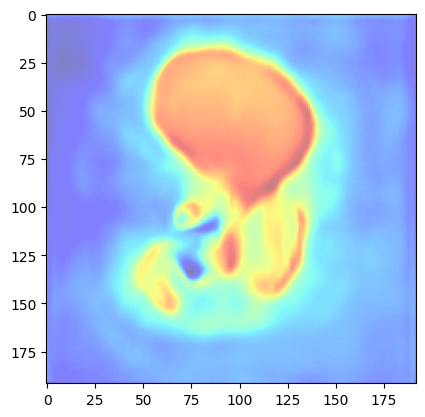

In [16]:
# images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg"
text = "Please segment all the organs."

images="/qumulo/shared_data/aofei_summer/data/BiomedParse/amos22/amos22/CT/train/amos_0353_190_CT_abdomen.png"
# text = "Please segment and focus on the postcava in this CT, then determine if there is any focal lesion or abnormality by answering yes or no."
# text = "Please segment the liver."

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

In [8]:
seg_logits

tensor([[[[-22.1250, -22.1250, -22.1250,  ..., -20.8750, -21.0000, -21.6250],
          [-20.8750, -20.2500, -20.1250,  ..., -19.8750, -19.8750, -20.5000],
          [-21.5000, -21.2500, -21.0000,  ..., -20.1250, -20.1250, -20.8750],
          ...,
          [-19.2500, -18.8750, -19.2500,  ..., -18.1250, -17.6250, -18.2500],
          [-19.3750, -19.0000, -19.3750,  ..., -17.7500, -17.6250, -18.3750],
          [-20.7500, -21.1250, -21.0000,  ..., -18.6250, -18.2500, -19.7500]]]],
       device='cuda:0', dtype=torch.bfloat16)

torch.Size([1, 12, 4096])
['assistant\nSpleen segmented as [M0_7].']


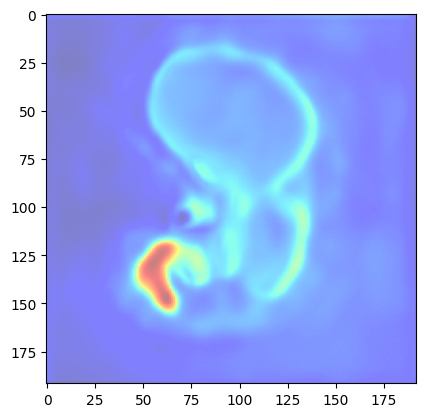

In [9]:
# images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg"
# text = "Please segment all the organs."

images="/qumulo/shared_data/aofei_summer/data/BiomedParse/amos22/amos22/CT/train/amos_0353_190_CT_abdomen.png"
# text = "Please segment and focus on the aorta in this CT, then determine if there is any focal lesion or abnormality by answering yes or no."
text = "Please segment the spleen."

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

torch.Size([1, 16, 4096])
['assistant\nA malignant breast tumor is identified and segmented as [M2_11].']


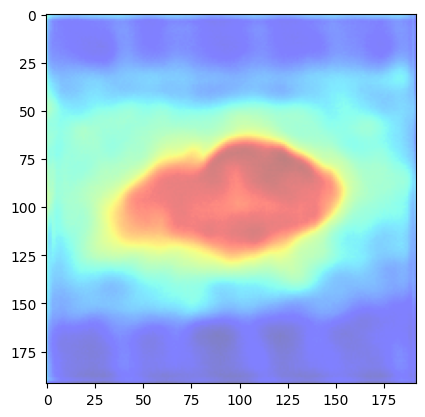

In [10]:
# images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg"
# text = "Please segment all the organs."

images="/qumulo/shared_data/aofei_summer/data/BiomedParse/BreastUS/BreastUS/test/malignant (86)_ultrasound_breast.png"
# text = "Please segment and focus on the aorta in this CT, then determine if there is any focal lesion or abnormality by answering yes or no."
text = "On breast ultrasound, what abnormality is identified and how would you segment it?"

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

['Findings consistent with a brain tumor (including enhancing and non-enhancing components) are present; segmented as [M10_3].']


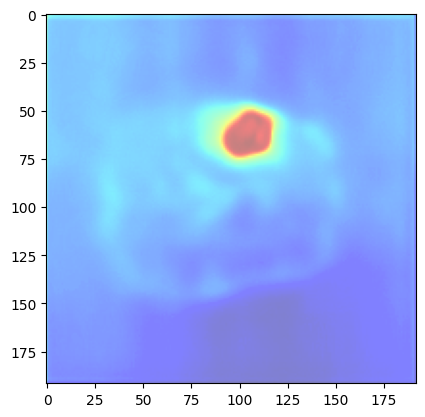

In [27]:
# images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg"
# text = "Please segment all the organs."

images='/qumulo/shared_data/aofei_summer/data/BiomedParse/MSD/MSD/Task01_BrainTumour/test/BRATS_415_77_MRI-T1-Gd_brain.png'
# text = "Please segment and focus on the aorta in this CT, then determine if there is any focal lesion or abnormality by answering yes or no."
text = 'What abnormality is present in this brain MRI region? Please provide the diagnosis and segment it.'

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

['The non-enhancing portion of the lesion on the post-contrast (T1-Gd) brain MRI shows an area that is hypointense compared to normal white matter. This abnormality suggests a region with altered tissue characteristics, potentially indicative of a tumor or other pathology. The segmentation of this hypointense area is provided as [M10_3].']


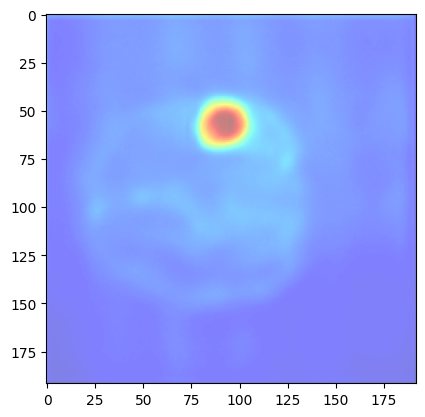

In [19]:
# images="/qumulo/shared_data/aofei_summer/data/evaluation/imgs/xmlab102/source.jpg"
# text = "Please segment all the organs."

images='/qumulo/shared_data/aofei_summer/data/BiomedParse/MSD/MSD/Task01_BrainTumour/test/BRATS_429_51_MRI-T1-Gd_brain.png'
# text = "Please segment and focus on the aorta in this CT, then determine if there is any focal lesion or abnormality by answering yes or no."
text = "On the post-contrast (T1-Gd) brain MRI, what abnormality is present in the non-enhancing portion of the lesion? Please segment it."

answers, seg_logits = segment_image(images, text)
print(answers)
# visualize the mask logits
plt.imshow(seg_logits[0][0].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')

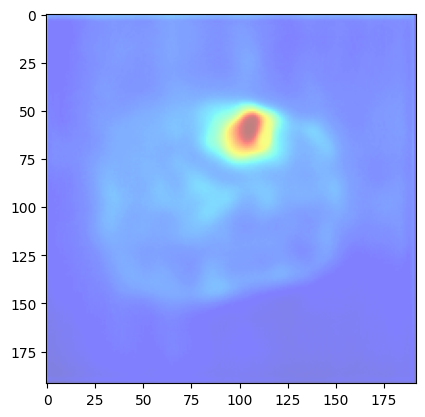

In [12]:
plt.imshow(seg_logits[0][1].float().detach().cpu().numpy(), alpha=0.5, cmap='jet')